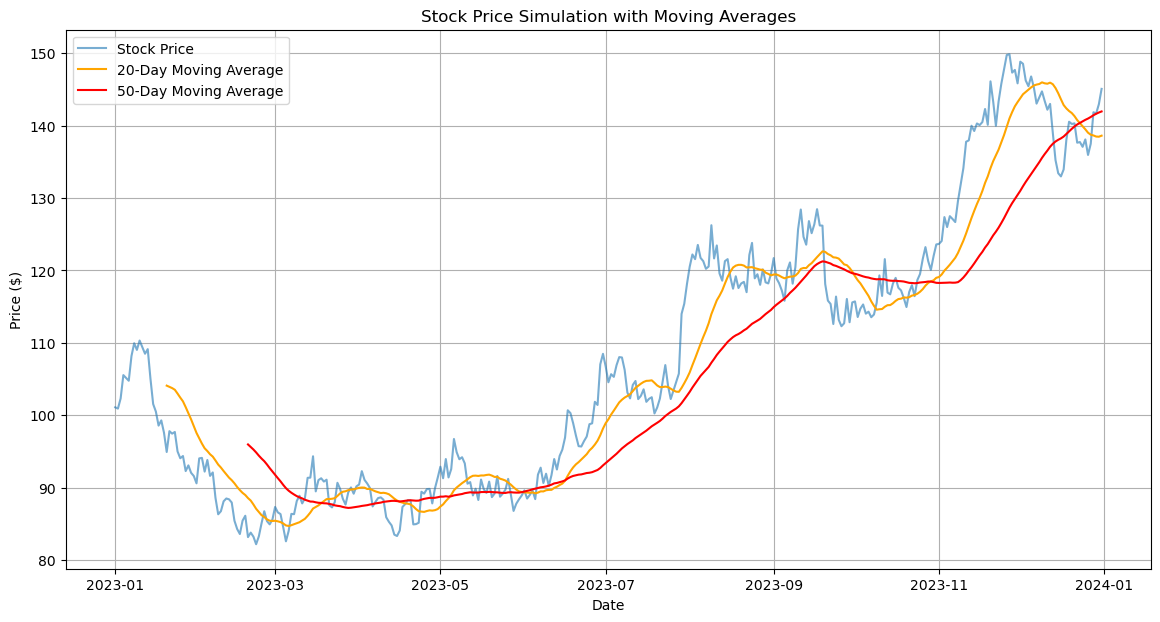

Daily Return Mean: 0.0011721825634280166
Volatility: 0.018980225239213052
Cumulative Return: 0.43517188473860857


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=365)
returns = np.random.normal(0.001, 0.02, 365)
price_series = 100 * (1 + returns).cumprod()

df = pd.DataFrame({'Date': dates, 'Price': price_series})
df.set_index('Date', inplace=True)

df['MA20'] = df['Price'].rolling(window=20).mean()
df['MA50'] = df['Price'].rolling(window=50).mean()

daily_return_mean = df['Price'].pct_change().mean()
volatility = df['Price'].pct_change().std()
cumulative_return = (df['Price'].iloc[-1] / df['Price'].iloc[0]) - 1

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Price'], label='Stock Price', alpha=0.6)
plt.plot(df.index, df['MA20'], label='20-Day Moving Average', color='orange')
plt.plot(df.index, df['MA50'], label='50-Day Moving Average', color='red')

plt.title('Stock Price Simulation with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Daily Return Mean: {daily_return_mean}")
print(f"Volatility: {volatility}")
print(f"Cumulative Return: {cumulative_return}")